# Проект. Исследование стартапов

* Автор: Федорова Марина Вячеславовна
* Дата: 05.01.2026

<a class="ancor" id="1-bullet"></a>
## Введение

### Цели и задачи проекта
Используем датасет, содержащий информацию о компаниях, объёмах и типах привлеченных инвестиций и статистику по возвратам средств. Исследуем динамику и структуру финансирования стартапов. Проведём исследование на исторических данных.

<a class="ancor" id="19-bullet"></a>
<a class="ancor" id="3-bullet"></a>
### Содержание проекта:
1. [Введение](#1-bullet)
    * [Цели и задачи проекта](#2-bullet)
    * [Содержание проекта](#3-bullet)
    
    
2. [Знакомство с данными: загрузка и предобработка](#4-bullet)
    * [Вывод общей информации](#5-bullet)
    * [Предобработка данных](#6-bullet)
    
    
3. [Инжиниринг признаков](#7-bullet)
    * [Группы по срокам финансирования](#8-bullet)
    * [Выделение средних и нишевых сегментов рынка](#9-bullet)
    
    
4. [Работа с выбросами и анализ](#10-bullet)
    * [Анализ выбюросов в каждом из сегментов](#11-bullet)
    * [Определение границы рассматриваемого периода](#12-bullet)
    * [Анализ типов финансирования по объёму и популярности](#13-bullet)
    
    
5. [Анализ динамики](#14-bullet)
    * [Динамика предоставления финансирования по годам](#15-bullet)
    * [Динамика размера общего финансирования для растущих в 2014 году сегментов](#16-bullet)
    * [Годовая динамика доли возвращённых средств по типам финансирования](#17-bullet)
    
    
6. [Итоговый вывод и рекомендации](#18-bullet)

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.


[Назад к содержанию](#19-bullet)

---
<a class="ancor" id="5-bullet"></a>
### 1.1. Вывод общей информации

Загрузим необходимые для работы библиотеки.


In [1]:
# Устанавливаем библиотеку phik
!pip install phik -U

# Импортируем библиотеку pandas
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi-k
from phik import phik_matrix

import warnings
warnings.filterwarnings("ignore")
import numpy as np

Загрузим все данные по проекту.

Совет: данные из zip-архива можно загрузить следующим кодом:

`df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)`

In [2]:
# Загружаем данные из датасета cb_investments.zip в переменную invest_info_df
invest_info_df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [3]:
# Загружаем данные из датасета cb_returns.csv в переменную fin_return_df
fin_return_df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv")

Выведем информацию, которая необходима для принятия решений о предобработке.

In [4]:
# Выводим информацию о датафрейме invest_info_df
invest_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [5]:
# Выводим первые строки датафрейма invest_info_df
invest_info_df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# Выводим информацию о датафрейме fin_return_df
fin_return_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [7]:
# Выводим первые строки датафрейма fin_return_df
fin_return_df.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


Датасет `cb_investments.zip` содержит `54294` строки и `40` столбцов. 24 столбца с типом данных `float64` и 16 столбцов с типом данных `object`. 
* При первичном знакомстве с данными можно обнаружить пробелы в начале названий столбцов `market`  и `funding_total_usd`, которые необходимо будет удалить для проведения дальнейшего анализа. 
* В столбцах `funding_rounds` и `participants` можно провести оптимизацию типа даннных путём понижения разрядности, т.к. столбцы содержат информацию об общем числе раундов и количестве участников в раундах финансирования и если в столбцах нет аномалий, маловероятно что они содержат высокие значения.
* Столбцы, содержащие информацию о датах можно перевести в тип данных `datetime64`.
* Пропуски встречаются во всех столбцах. В столбце `mid_funding_at` пропущенные значения заменим средним значением разницы `last_funding_at` и `first_funding_at`.
* В столбце `funding_total_usd` уберём разрядность и приведём к числовому типу данных.

Датасет `cb_returns.csv` содержит `15` строк и `14` столбцов. 13 столбцов с типом данных `float64` и 1 столбец с целочисленным типом данных `int64`. 
* Пропусков в данном датасете не обнаружилось.
* Столбец `year` сделаем индексом всего датасета.

Создадим копию датафрейма `invest_info_df` до преобразования данных для возможности проверки сделанных изменений после проведенной предобработки.

In [8]:
copy_invest = invest_info_df.copy()
copy_invest.shape[0]

54294

[Назад к содержанию](#19-bullet)

---
<a class="ancor" id="6-bullet"></a>
### 1.2. Предобработка данных

Подготовим данные к исследовательскому анализу.

In [9]:
# Выведем количество пропущенных значений
def show_missing_values(tmp0):
    missing_values = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_values = missing_values[missing_values['Кол-во пропусков'] > 0]
    
    if missing_values.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return (missing_values.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_values(invest_info_df)

,Кол-во пропусков,Доля пропусков
name,4857,0.0895
homepage_url,8305,0.1530
category_list,8817,0.1624
market,8817,0.1624
funding_total_usd,4856,0.0894
status,6170,0.1136
country_code,10129,0.1866
state_code,24133,0.4445
region,10129,0.1866
city,10972,0.2021


Проверим названия столбцов в датасетах и при необходимости приведите их к единому аккуратному стилю.

In [10]:
# Удалим лишние пробелы в названиях столбцов
invest_info_df.columns = invest_info_df.columns.str.strip()

Уберём в столбце `funding_total_usd` выделение разрядов и приведём его к числовому типу.

In [11]:
# Удалим разделители между разрядами в числовых данных
invest_info_df['funding_total_usd'] = invest_info_df['funding_total_usd'].str.replace(',', '').str.replace(' ','')

In [12]:
# Приведём 'funding_total_usd' к числовому типу
invest_info_df['funding_total_usd'] = pd.to_numeric(invest_info_df['funding_total_usd'], errors='coerce')

Обработаем типы данных в столбцах founded_at, first_funding_at, last_funding_at, mid_funding_at, которые хранят значения даты и времени.

In [13]:
# Приведём столбцы к типу datetime64
for column in ['founded_at', 'founded_quarter', 'first_funding_at', 'last_funding_at', 'mid_funding_at']:
    invest_info_df[column] = pd.to_datetime(invest_info_df[column], errors='coerce')

В датасете `cb_returns` сделаем столбец `year` индексом всего датасета.

In [14]:
# Назначим столбец 'year' индексом
fin_return_df = fin_return_df.set_index('year')

Обработаем текстовые данные. Пропуски в столбцах `country_code`, `state_code`, `region`, `founded_month`, `founded_quarter` заполним заглушками.

In [15]:
# Заменим пропуски значением-индикатором
invest_info_df[['country_code', 'state_code', 'region']] = invest_info_df[['country_code', 'state_code', 'region']].fillna(0)
invest_info_df[['founded_month', 'founded_quarter']] = invest_info_df[['founded_month', 'founded_quarter']].fillna(-1)

Обработаем полные дубликаты в данных и пропуски в `funding_total_usd`. Удалим те строки, которые не несут какой-либо информации, либо не содержат данных о финансировании.

In [16]:
# Переведём строки столбца 'name' в нижний регистр и удалим пробелы
invest_info_df['name'] = invest_info_df['name'].str.lower().str.strip()

In [17]:
# Переведём строки столбца 'market' в нижний регистр и удалим пробелы
invest_info_df['market'] = invest_info_df['market'].str.lower().str.strip()

In [18]:
# Проверим полные дубликаты в датафрейме
invest_info_df.duplicated().sum()

4855

In [19]:
# Фильтруем строки с пропусками
filtered_df = invest_info_df[invest_info_df['funding_total_usd'].isna()]

# Удаляем дубликаты в отфильтрованном датафрейме
filtered_df = filtered_df.drop_duplicates()

# Объединим получившийся датафрейм с исходным
invest_info_df = pd.concat([invest_info_df[~invest_info_df['funding_total_usd'].isna()], filtered_df])

Заполним пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмём приблизительно середину интервала между этими двумя датами.

In [20]:
# Заполняем пропуски в 'mid_funding_at'
def avg_mid(row):
    if pd.isna(row['mid_funding_at']):
        avg = row['first_funding_at'] + (row['last_funding_at'] - row['first_funding_at']) / 2
        return avg
    else:
        return row['mid_funding_at']

In [21]:
# Применим функцию к столбцу
invest_info_df['mid_funding_at'] = invest_info_df.apply(avg_mid, axis=1)

In [22]:
# Оценим размер оставшихся пропусков
show_missing_values(invest_info_df)

,Кол-во пропусков,Доля пропусков
name,2,0.0000
homepage_url,3450,0.0698
category_list,3962,0.0801
market,3962,0.0801
funding_total_usd,8532,0.1726
status,1315,0.0266
city,6117,0.1237
funding_rounds,1,0.0000
participants,18966,0.3836
founded_at,10886,0.2202


In [23]:
# Проверим сколько удалено строк датасета
a, b = copy_invest.shape[0], invest_info_df.shape[0]
display('Было строк в исходном датасете:', a)
display('Осталось строк в датасете после обработки:', b)
display('Удалено строк в датасете после обработки:', a-b)
display('Процент потерь:', round((a-b)/a*100, 2))

'Было строк в исходном датасете:'

54294

'Осталось строк в датасете после обработки:'

49439

'Удалено строк в датасете после обработки:'

4855

'Процент потерь:'

8.94

### Промежуточный вывод

* В процессе предобработки данных заменили пропуски в столбцах `country_code`, `state_code`, `region`, `founded_month`, `founded_quarter` значениями-индикаторами. 
* Удалили полные дубликаты, которые не содержали информацию о финансировании. 
* Заменили пропущенные значения в столбце `mid_funding_at` приблизительно серединой интервала между столбцами `first_funding_at` и `last_funding_at`. 
Процент удаленных строк составил `8.94`.
* Также привели данные в столбцах `founded_at`, `first_funding_at`, `last_funding_at`, `mid_funding_at`, которые хранят значения даты и времени, в тип данных `datetime64`. Изменили разрядность данных в столбцах `funding_rounds` и `participants`.
* В столбце funding_total_usd убрали выделение разрядов и привели его к числовому типу.
* В датасете `cb_returns` назначили столбец `year` индексом всего датасета.

[Назад к содержанию](#19-bullet)

---
<a class="ancor" id="7-bullet"></a>
## Шаг 2. Инжиниринг признаков

<a class="ancor" id="8-bullet"></a>
### 2.1. Группы по срокам финансирования

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируем соотношение этих групп, создав два графика:

* По количеству компаний: отобразим какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: покажем, какую долю от общего объёма привлечённых средств получила каждая группа.


In [24]:
# Используем функцию для категоризации компаний
def group_company(row):
    if row['funding_rounds'] == 1:
        return "Единичное финансирование"
    elif (row['last_funding_at'] - row['first_funding_at']).days < 365:
        return "Срок финансирования до года"
    elif (row['last_funding_at'] - row['first_funding_at']).days > 365:
        return "Срок финансирования более года"
    else: 
        return "Без категории"

In [25]:
# Применение функции ко всем строкам
invest_info_df['category'] = invest_info_df.apply(group_company, axis=1)
invest_info_df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,category
0,harvard university,http://harvard.edu,|Education|,education,90000000.0,operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
1,university of new brunswick,http://www.unb.ca,NaN,NaN,2000000.0,operating,0,0,0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
2,dupont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,business services,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование
3,university of michigan,http://www.umich.edu/,|Education|,education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Срок финансирования до года
4,case western reserve university,http://www.case.edu,|Education|,education,540000.0,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование


In [26]:
# Проверяем распределение данных по значениям столбца 'category' в относительных значениях
display('Количество компаний в относительном значении по каждой категории:')
invest_info_df['category'].value_counts(normalize=True) 

'Количество компаний в относительном значении по каждой категории:'

Единичное финансирование          0.648051
Срок финансирования более года    0.255021
Срок финансирования до года       0.094601
Без категории                     0.002326
Name: category, dtype: float64

In [27]:
# Определяем цветовую палитру
colors = ['grey', 'skyblue', 'turquoise','blue']

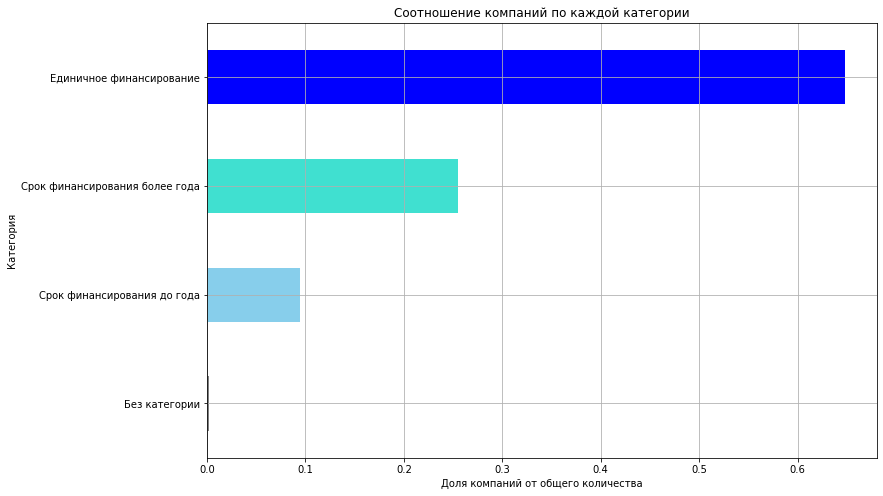

In [28]:
# Создаём контейнер графика matplotlib и задаём размер
plt.figure(figsize=(12, 8))

# Строим линейчатую диаграмму
invest_info_df['category'].value_counts(normalize=True).sort_values().plot(
                    kind='barh',
                    legend=False,
                    title='Соотношение компаний по каждой категории',
                    color=colors)

# Настраиваем оформление графика
plt.xlabel('Доля компаний от общего количества')
plt.ylabel('Категория')
# Добавляем сетку графика
plt.grid()
# Выводим график
plt.show()

In [29]:
# Проверяем распределение данных по значениям столбца 'category' в относительных значениях
display('Количество привлеченных средств в относительном значении по каждой категории:')
group_invest = invest_info_df.groupby('category')['funding_total_usd'].sum()
total_sum = group_invest.sum()
share = group_invest / total_sum
display(share)

'Количество привлеченных средств в относительном значении по каждой категории:'

category
Без категории                     0.001636
Единичное финансирование          0.306182
Срок финансирования более года    0.618664
Срок финансирования до года       0.073518
Name: funding_total_usd, dtype: float64

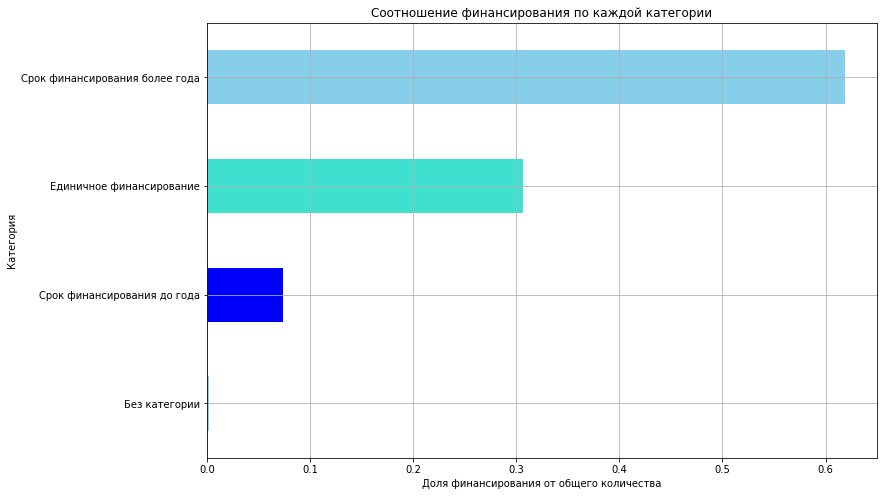

In [30]:
# Создаём контейнер графика matplotlib и задаём размер
plt.figure(figsize=(12, 8))

# Строим линейчатую диаграмму
share.sort_values().plot(
                    kind='barh',
                    legend=False,
                    title='Соотношение финансирования по каждой категории',
                    color=['skyblue', 'blue', 'turquoise'])

# Настраиваем оформление графика
plt.xlabel('Доля финансирования от общего количества')
plt.ylabel('Категория')
# Добавляем сетку графика
plt.grid()
# Выводим график
plt.show()

* Судя по графику соотношений количества, компании, которые финансировались единично встречаются наиболее чаще, чем те, чей срок финансирования превышал год. `Единичное финансирование` превышает `финансирование более года` более чем в 2,5 раза. 
* По графику соотношений доли финансирования можно увидеть, что категория `срок финансирования более года` является основным лидером, его доля составляет более `62 %`. `Срок финансирования до года` менее популярен, всего `7 %`.

[Назад к содержанию](#19-bullet)

---
<a class="ancor" id="9-bullet"></a>
### 2.2 Выделение средних и нишевых сегментов рынка

Рассчитаем как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесём к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесём к средним, а сегменты до 35 компаний отнесём к нишевым. Рассчитаем сколько сегментов попадает в каждую из категорий.

In [31]:
# Сгруппируем компании по сегментам
segment = invest_info_df.groupby('market')['name'].count().sort_values(ascending=False)
segment

market
software                          5489
biotechnology                     3761
mobile                            2725
e-commerce                        2283
curated web                       2088
                                  ... 
musicians                            1
embedded hardware and software       1
retail technology                    1
medical marijuana patients           1
data integration                     1
Name: name, Length: 439, dtype: int64

In [32]:
# Используем функцию для выдедления сегментов
def group_segment(row):
    count = segment.get(row['market'], 0)  # Получаем количество компаний для текущего рынка
    if count > 120:
        return "Массовые"
    elif count > 35:
        return "Средние"
    else: 
        return "Нишевые"

In [33]:
# Применение функции ко всем строкам
invest_info_df['segments'] = invest_info_df.apply(group_segment, axis=1)
invest_info_df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,category,segments
0,harvard university,http://harvard.edu,|Education|,education,90000000.0,operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Массовые
1,university of new brunswick,http://www.unb.ca,NaN,NaN,2000000.0,operating,0,0,0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Нишевые
2,dupont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,business services,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Средние
3,university of michigan,http://www.umich.edu/,|Education|,education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Срок финансирования до года,Массовые
4,case western reserve university,http://www.case.edu,|Education|,education,540000.0,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Массовые


In [34]:
# Фильтруем по средним и нишевым сегментам
filtered_segments = invest_info_df[invest_info_df['segments'].isin(['Нишевые', 'Средние'])]
segment_counts = filtered_segments.groupby('market')['name'].count().sort_values(ascending=False).reset_index(name='count')
 
# Определяем медиану и границы среднего сегмента 
median = segment_counts['count'].median() 
# Определим нижнюю границу среднего сегмента
lower_bound = 35  
# Определим верхнюю границу среднего сегмента segment_counts
upper_bound = 120  

<Figure size 864x576 with 0 Axes>

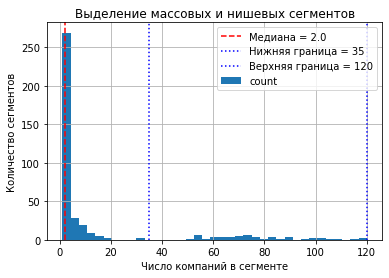

In [35]:
# Создаём контейнер графика matplotlib и задаём размер
plt.figure(figsize=(12, 8))

# Строим гистограмму
segment_counts.plot(
                    kind='hist',
                    bins=37,
                    legend=False,
                    title='Выделение массовых и нишевых сегментов'
                    )

plt.axvline(x=median, color='red', linestyle='--', label=f'Медиана = {median:.1f}')
plt.axvline(x=lower_bound, color='blue', linestyle=':', label=f'Нижняя граница = {lower_bound}')
plt.axvline(x=upper_bound, color='blue', linestyle=':', label=f'Верхняя граница = {upper_bound}')
plt.legend()  # добавляем легенду

# Настраиваем оформление графика
plt.ylabel('Количество сегментов')
plt.xlabel('Число компаний в сегменте')

# Добавляем сетку графика
plt.grid()
# Выводим график
plt.show()

Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования будем выполнять с учётом этой замены.


In [36]:
# Используем функцию для замены значений
def mass_segment(row):
    if row['segments'] == "Массовые":
        return row['market']
    elif row['segments'] == "Средние":
        return "mid"
    else: 
        return "niche"

In [37]:
# Применение функции ко всем строкам
invest_info_df['market'] = invest_info_df.apply(mass_segment, axis=1)
invest_info_df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,category,segments
0,harvard university,http://harvard.edu,|Education|,education,90000000.0,operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Массовые
1,university of new brunswick,http://www.unb.ca,NaN,niche,2000000.0,operating,0,0,0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Нишевые
2,dupont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,mid,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Средние
3,university of michigan,http://www.umich.edu/,|Education|,education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Срок финансирования до года,Массовые
4,case western reserve university,http://www.case.edu,|Education|,education,540000.0,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Массовые


Построим график распределения количества компаний в сегментах и отобразим на нём разделение на нишевые и средние сегменты.

In [38]:
# Проверим распределение количества компаний в каждой группе сегментов в относительных значенииях
display('Количество компаний в сегментах:')
invest_info_df['segments'].value_counts(normalize=True).sort_values(ascending=False)

'Количество компаний в сегментах:'

Массовые    0.817371
Нишевые     0.102328
Средние     0.080301
Name: segments, dtype: float64

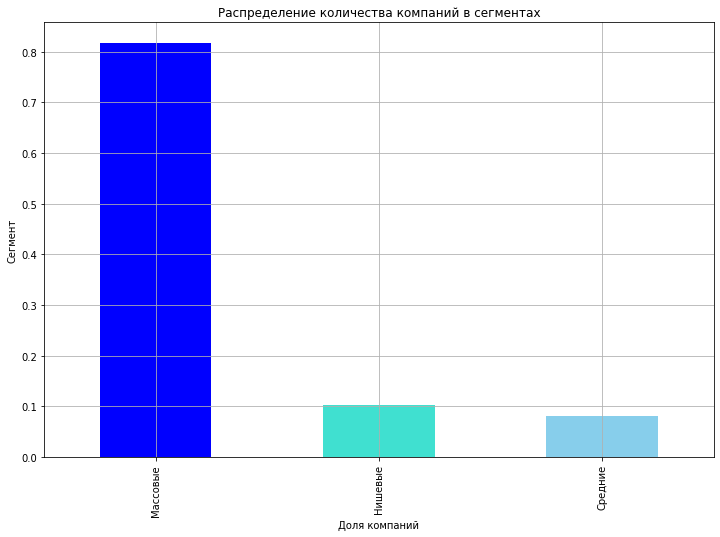

In [39]:
# Создаём контейнер графика matplotlib и задаём размер
plt.figure(figsize=(12, 8))

# Строим столбчатую диаграмму
invest_info_df['segments'].value_counts(normalize=True).sort_values(ascending=False).plot(
                    kind='bar',
                    legend=False,
                    title='Распределение количества компаний в сегментах',
                    color=['blue', 'turquoise', 'skyblue'])

# Настраиваем оформление графика
plt.xlabel('Доля компаний')
plt.ylabel('Сегмент')
# Добавляем сетку графика
plt.grid()
# Выводим график
plt.show()

Проанализировав распределение сегментов, можно уверенно сказать, что компаний в `массовом` сегменте рынка практически в восемь раз больше остальных, практически `82 %`.

[Назад к содержанию](#19-bullet)

---
<a class="ancor" id="10-bullet"></a>
## Шаг 3. Работа с выбросами и анализ

<a class="ancor" id="11-bullet"></a>
### 3.1. Анализируем и помечаем выбросы в каждом из сегментов


По предобработанному столбцу `funding_total_usd` графическим образом оценим какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажем интервал, в котором лежат типичные значения.

In [40]:
# Изучаем статистические показатели столбца 'funding_total_usd'
display('Статистические показатели столбца funding_total_usd:')
invest_info_df['funding_total_usd'].describe()

'Статистические показатели столбца funding_total_usd:'

count    4.090700e+04
mean     1.591253e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

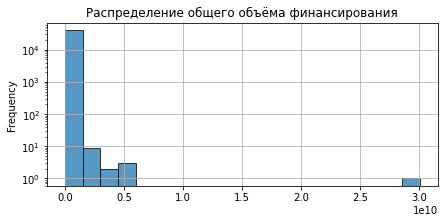

In [41]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
invest_info_df['funding_total_usd'].plot(
                kind='hist',
                xlabel='Общий объём финансирования',
                ylabel='Количество компаний',
                bins=20, 
                alpha=0.75,
                edgecolor='black',
                rot=0,
                log=True  # Включаем логарифмическую шкалу
)

# Настраиваем оформление графика
plt.title('Распределение общего объёма финансирования')

# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

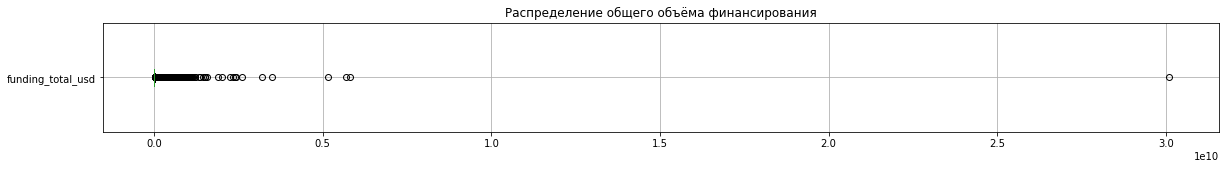

In [42]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(20, 2))

# Строим диаграмму размаха значений в столбце seats
invest_info_df.boxplot(column='funding_total_usd', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение общего объёма финансирования')

# Выводим график
plt.show()

Определим компании с аномальным объёмом общего финансирования, используя метод IQR отдельно по каждому сегменту. 


In [43]:
# Разделим данные на сегменты
niche_segment = invest_info_df[invest_info_df['segments'] == 'Нишевые']
mid_segment = invest_info_df[invest_info_df['segments'] == 'Средние']
mass_segment = invest_info_df[invest_info_df['segments'] == 'Массовые']

In [44]:
# Используем функцию для определения IQR
def find_anomalies(group):
    Q1 = group['funding_total_usd'].quantile(0.25)
    Q3 = group['funding_total_usd'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Нижний порог выбросов': lower_bound,
        'Верхний порог выбросов': upper_bound
    }

In [45]:
# Применим функцию к каждому сегменту
anomalous_niche = find_anomalies(niche_segment)
anomalous_mid = find_anomalies(mid_segment)
anomalous_mass = find_anomalies(mass_segment)

In [46]:
# Выводим результаты
display("Значения IQR для нишевых сегментов:")
display(anomalous_niche)

display("Значения IQR для средних сегментов:")
display(anomalous_mid)

display("Значения IQR для массовых сегментов:")
display(anomalous_mass)

'Значения IQR для нишевых сегментов:'

{'Q1': 75000.0,
 'Q3': 3000000.0,
 'IQR': 2925000.0,
 'Нижний порог выбросов': -4312500.0,
 'Верхний порог выбросов': 7387500.0}

'Значения IQR для средних сегментов:'

{'Q1': 250000.0,
 'Q3': 7867501.0,
 'IQR': 7617501.0,
 'Нижний порог выбросов': -11176251.5,
 'Верхний порог выбросов': 19293752.5}

'Значения IQR для массовых сегментов:'

{'Q1': 450000.0,
 'Q3': 10295338.5,
 'IQR': 9845338.5,
 'Нижний порог выбросов': -14318007.75,
 'Верхний порог выбросов': 25063346.25}

На основе сравнения IQR для разных сегментов можно сделать вывод, что `массовые сегменты` имеют наибольший разброс данных, что указывает на высокую вариативность и нестабильность финансирования. Значения ниже `-14318007.75` и выше `25063346.25` можно считать аномальными.

Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ таких сегментов.

In [47]:
# Подсчитываем общее количество компаний по каждой отрасли
count_company = mass_segment['market'].value_counts()

# Фильтруем по 'segments'
mass_segment = invest_info_df.loc[invest_info_df['segments'] == 'Массовые']

# Вычисляем границы для сегмента
anomalous_mass = find_anomalies(mass_segment)
lower_bound_mass = anomalous_mass['Нижний порог выбросов']
upper_bound_mass = anomalous_mass['Верхний порог выбросов']

# Добавляем границы в датафрейм
mass_segment.loc[:, 'lower_bound'] = lower_bound_mass
mass_segment.loc[:, 'upper_bound'] = upper_bound_mass

# Фильтруем данные для аномальных значений
anomalous_data = mass_segment[(mass_segment['funding_total_usd'] < mass_segment['lower_bound']) | 
                              (mass_segment['funding_total_usd'] > mass_segment['upper_bound'])]

# Подсчитываем количество компаний с аномальным финансированием по каждой отрасли
anomalous_count = anomalous_data['market'].value_counts()

# Создаем DataFrame для хранения данных
segment_anomalies = pd.DataFrame({
    'отрасль компании': count_company.index,
    'количество компаний': count_company.values,
    'компании с аномальным финансированием': anomalous_count.values
})

# Вычисляем долю компаний c аномальным финансированием
segment_anomalies['доля'] = segment_anomalies['компании с аномальным финансированием']/ segment_anomalies['количество компаний'] * 100

# Сортируем по убыванию и выводим топ
top_markets = segment_anomalies.sort_values('доля', ascending=False)
top_markets.head(15)

,отрасль компании,количество компаний,компании с аномальным финансированием,доля
0,software,5489,802,14.611040
6,games,1374,191,13.901019
5,enterprise software,1557,215,13.808606
3,e-commerce,2283,315,13.797635
17,security,626,84,13.418530
1,biotechnology,3761,456,12.124435
2,mobile,2725,318,11.669725
8,health care,1294,149,11.514683
7,clean technology,1324,152,11.480363
16,analytics,760,84,11.052632


In [48]:
# Используем функцию для определения типичной медианы
def find_median(group):
    median = group['funding_total_usd'].median()
    return {'Типичная медиана': median}

In [49]:
# Применим функцию к каждому сегменту
typical_median_niche = find_median(niche_segment)
typical_median_mid = find_median(mid_segment)
typical_median_mass = find_median(mass_segment)

In [50]:
# Выводим результаты
display("Значения для нишевых сегментов:")
display(typical_median_niche)

display("Значения для средних сегментов:")
display(typical_median_mid)

display("Значения для массовых сегментов:")
display(typical_median_mass)

'Значения для нишевых сегментов:'

{'Типичная медиана': 500000.0}

'Значения для средних сегментов:'

{'Типичная медиана': 1400000.0}

'Значения для массовых сегментов:'

{'Типичная медиана': 2250000.0}

Сегменты рынка, с наибольшей долей компаний, получивших аномальные финансирования стали `software` (802 компании), `games` (191 компания) и `enterprise software` (215 компаний).

На основании полученных данных методом `describe` можно сделать вывод, что среднее (1.591253e+07) значительно выше медианны (2.000000e+06). Поэтому для анализа "типичных" значений лучше использовать медиану, т.к. она менее чувствительна к выбросам.
Большинство компаний получили финансирование от `350 000` до `10 000 000` долларов, что является "типичной" частью выборки. `Типичная медиана` для `нишевых` сегментов составила `500 000` долларов, для `средних` - `1 400 000`, для `массовых` сегментов - `2 250 000` долларов.

[Назад к содержанию](#19-bullet)

---
<a class="ancor" id="12-bullet"></a>
### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим по датасету, можно ли считать, что нам предоставили полные данные за 2014 год. Затем исключим из датасета компании, которые ранее посчитали получившими аномальное финансирование.

После исключения аномальных записей, на основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только об определённых компаниях: они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [51]:
# Фильтруем данные за 2014 год
year_2014 = invest_info_df[invest_info_df['mid_funding_at'].dt.year == 2014]

# Проверяем наличие данных за каждый месяц
monthly_2014 = year_2014.groupby(year_2014['mid_funding_at'].dt.month).size()

# Выводим результат
display(monthly_2014)
display('Общее количество записей за 2014 год:')
year_2014.shape[0]

mid_funding_at
1     1013
2      750
3      829
4      818
5      774
6      932
7      874
8      774
9      699
10     651
11     362
12      30
dtype: int64

'Общее количество записей за 2014 год:'

8506

In [52]:
# Создаём список названий компаний с аномальным финансированием
anomalous_companies = anomalous_data['name'].unique()

# Исключаем эти компании из исходного датасета
invest_info_df = invest_info_df[~invest_info_df['name'].isin(anomalous_companies)]
invest_info_df.shape[0]

44962

In [53]:
# Группируем данные по году
grouped_year = invest_info_df.groupby(invest_info_df['mid_funding_at'].dt.year)['funding_rounds'].sum()

# Фильтруем данные по количеству раундов
filtered_group = grouped_year[grouped_year >= 50].index

# Применим фильтр к датафрейму
invest_filtered_df = invest_info_df[invest_info_df['mid_funding_at'].dt.year.isin(filtered_group)]

# Выводим первые строки для проверки
invest_filtered_df.head()
invest_filtered_df.shape[0]

44797

После исключения аномальных записей и фильтрации данных по годам, когда было зафиксировано 50 или более раундов финансирования строк в датафрейме осталось 44797 из 49439 предобработанных данных. Так как в датасете есть данные о финансировании за последний день года и о компаниях, основанных в последний месяц года, считаем, что данные за 2014 год полные.

[Назад к содержанию](#19-bullet)

---
<a class="ancor" id="13-bullet"></a>
### 3.3. Анализ типов финансирования по объёму и популярности

Построим график, который покажет какие типы финансирования в сумме привлекли больше всего денег. Будем ориентироваться на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравним графики и выделим часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

In [54]:
# Найдем общую сумму по типам финансирования
total_sum = invest_filtered_df[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 
                                'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market',
                                'product_crowdfunding']].sum().sort_values(ascending=False)
display('Общая сумма по типам финансирования:')
display(total_sum)

'Общая сумма по типам финансирования:'

venture                 1.402113e+11
private_equity          2.348701e+10
debt_financing          1.918789e+10
seed                    9.939301e+09
post_ipo_equity         7.424244e+09
post_ipo_debt           6.544809e+09
undisclosed             3.391923e+09
angel                   2.732324e+09
grant                   2.141965e+09
convertible_note        8.288211e+08
secondary_market        3.240862e+08
equity_crowdfunding     3.047023e+08
product_crowdfunding    2.129356e+08
dtype: float64

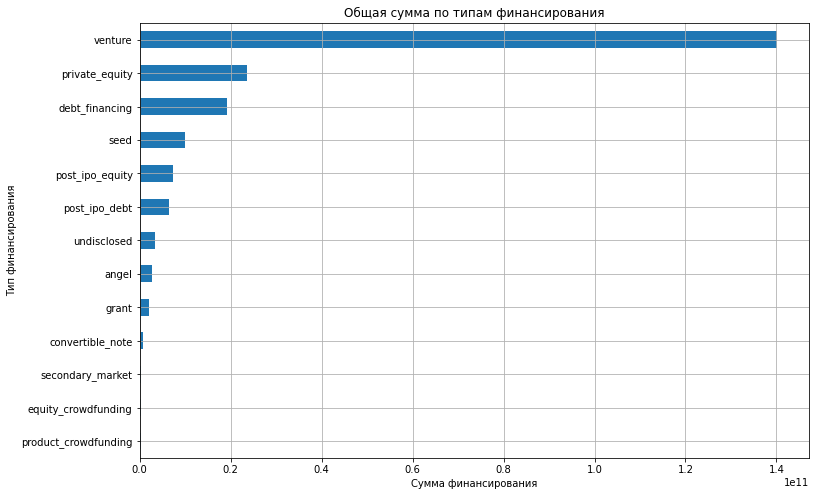

In [55]:
# Создаём контейнер графика matplotlib и задаём размер
plt.figure(figsize=(12, 8))

# Строим линейчатую диаграмму
total_sum.sort_values(ascending=True).plot(
                    kind='barh',
                    rot='0',
                    legend=False,
                    title='Общая сумма по типам финансирования')

# Настраиваем оформление графика
plt.ylabel('Тип финансирования')
plt.xlabel('Сумма финансирования')
# Добавляем сетку графика
plt.grid()
# Выводим график
plt.show()

Особенно популярным типом финансирования является `venture`. Общая сумма венчурных инвестиций составила 1.402113e+11 долларов США. Наименее популярен `product_crouwdfunding`. Общая сумма, привлечённая через продуктовый краудфандинг - 2.129356e+08.

In [56]:
# Найдем количество упоминаний типов финансирования в датасете
count_company = invest_filtered_df[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
                                    'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt',
                                    'secondary_market', 'product_crowdfunding']].apply(lambda x: (x > 0).sum(),
                                                                                       axis=0).sort_values(ascending=False)
display('Типы финансирования, используемые компаниями:')
display(count_company)

'Типы финансирования, используемые компаниями:'

venture                 19403
seed                    13555
debt_financing           3196
angel                    3015
grant                    1013
undisclosed               860
private_equity            712
equity_crowdfunding       522
convertible_note          513
product_crowdfunding      208
post_ipo_equity           168
post_ipo_debt              32
secondary_market            9
dtype: int64

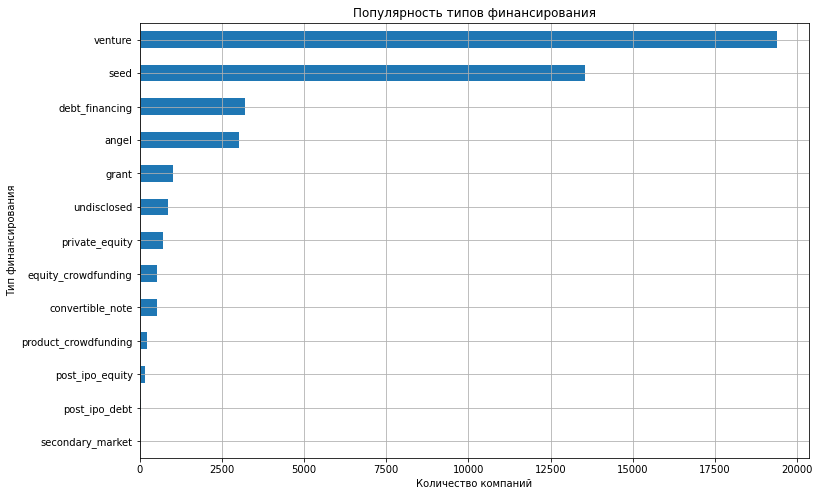

In [57]:
# Создаём контейнер графика matplotlib и задаём размер
plt.figure(figsize=(12, 8))

# Строим линейчатую диаграмму
count_company.sort_values(ascending=True).plot(
                    kind='barh',
                    rot='0',
                    legend=False,
                    title='Популярность типов финансирования')

# Настраиваем оформление графика
plt.ylabel('Тип финансирования')
plt.xlabel('Количество компаний')
# Добавляем сетку графика
plt.grid()
# Выводим график
plt.show()

Чаще всего компании используют `venture` (венчурные инвестиции) 19403 раза и `seed` (инвестиции на посевной стадии) 13555 раз.
А `сделки на вторичном рынке` и `долговое финансирование после IPO` наоборот - менее популярны.

Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

In [58]:
# Найдем суммарный объем возвратов
total_sum_return = fin_return_df[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 
                                'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market',
                                'product_crowdfunding']].sum().sort_values(ascending=False)
display('Суммарный объём возвратов по типам финансирования:')
display(total_sum_return)

'Суммарный объём возвратов по типам финансирования:'

venture                 40578.62
debt_financing           4734.85
private_equity           3587.33
seed                     2382.24
angel                    1509.23
post_ipo_equity          1104.96
undisclosed               730.88
post_ipo_debt              91.03
convertible_note           34.79
secondary_market            5.20
equity_crowdfunding         3.83
product_crowdfunding        1.86
grant                       0.00
dtype: float64

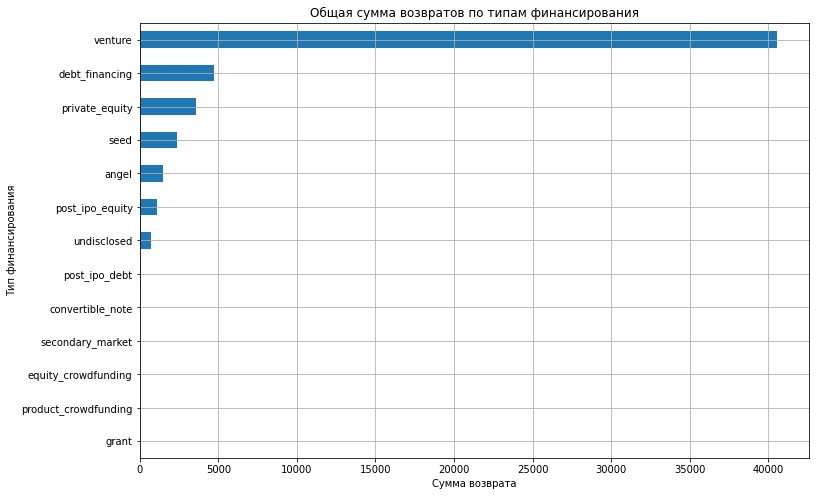

In [59]:
# Создаём контейнер графика matplotlib и задаём размер
plt.figure(figsize=(12, 8))

# Строим линейчатую диаграмму
total_sum_return.sort_values(ascending=True).plot(
                    kind='barh',
                    rot='0',
                    legend=False,
                    title='Общая сумма возвратов по типам финансирования')

# Настраиваем оформление графика
plt.ylabel('Тип финансирования')
plt.xlabel('Сумма возврата')
# Добавляем сетку графика
plt.grid()
# Выводим график
plt.show()

Судя по графику возвратов финансирования, тип финансирования `venture` снова является безусловным лидером - `40578.62` миллионов долларов США. По `grant` возвратов нет. 

* Венчурные инвестиции (`venture`) характеризуется и большим объемом финансирования и возврата, и наиболее часто встречающимся типом финансирования.
* Инвестиции в виде прямых (частных) вложений (`private_equity`) встречается редко, но характеризется большим объёмом финансирования и возврата. 
* Инвестиции от бизнес-ангелов (`angel`) встречается часто, но сумма финансирования характеризуется небольшим объёмом.
* Долговое финансирование после IPO (`post_ipo_debt`) характеризуется средними объёмами финансирования и возврата, но среди компаний встречается крайне редко.

[Назад к содержанию](#19-bullet)

---
<a class="ancor" id="14-bullet"></a>
## Шаг 4. Анализ динамики

<a class="ancor" id="15-bullet"></a>
### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитаем для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы построем графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

При построении графиков используем данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответим на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [60]:
# Рассчитываем средний объём финансирования на один раунд для каждой компании
invest_filtered_df['average_round_funding'] = invest_filtered_df['funding_total_usd'] / invest_filtered_df['funding_rounds']
invest_filtered_df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_B,round_C,round_D,round_E,round_F,round_G,round_H,category,segments,average_round_funding
1,university of new brunswick,http://www.unb.ca,NaN,niche,2000000.0,operating,0,0,0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Нишевые,2.000000e+06
2,dupont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,mid,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Средние,9.000000e+06
3,university of michigan,http://www.umich.edu/,|Education|,education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Срок финансирования до года,Массовые,2.566667e+06
4,case western reserve university,http://www.case.edu,|Education|,education,540000.0,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Массовые,5.400000e+05
5,xavier university,http://www.xavier.edu/,NaN,niche,19000000.0,operating,USA,OH,Cincinnati,Cincinnati,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Нишевые,1.900000e+07


In [61]:
invest_filtered_df['mid_funding_at'] = invest_filtered_df['mid_funding_at'].dt.year

In [62]:
avg_funding = invest_filtered_df.groupby('mid_funding_at')['average_round_funding'].median()
display('Средний размер средств в рамках одного раунда:')
display(avg_funding)

'Средний размер средств в рамках одного раунда:'

mid_funding_at
1998    1.362500e+06
1999    3.591639e+06
2000    3.250000e+06
2001    3.000000e+06
2002    3.776875e+06
2003    2.106293e+06
2004    3.560200e+06
2005    4.657750e+06
2006    4.000000e+06
2007    3.000000e+06
2008    2.185597e+06
2009    1.500000e+06
2010    1.250728e+06
2011    8.878750e+05
2012    7.214745e+05
2013    5.950000e+05
2014    6.607770e+05
Name: average_round_funding, dtype: float64

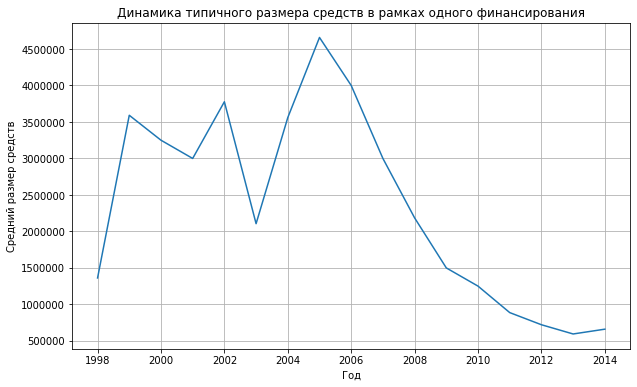

In [63]:
# Сгруппируем данные по годам и рассчитаем средний размер средств
avg_funding = invest_filtered_df.groupby('mid_funding_at')['average_round_funding'].median()

# Создаём контейнер графика matplotlib и задаём размер
plt.figure(figsize=(10, 6))

# Строим линейный график
avg_funding.plot(
                 kind='line',
                 legend=False,
                 title='Динамика типичного размера средств в рамках одного финансирования')

# Настраиваем оформление графика
plt.xlabel('Год')
plt.ylabel('Средний размер средств')

# Устанавливаем формат отображения значений на оси Y
plt.ticklabel_format(style='plain', axis='y')

# Добавляем сетку графика
plt.grid()
# Выводим график
plt.show()

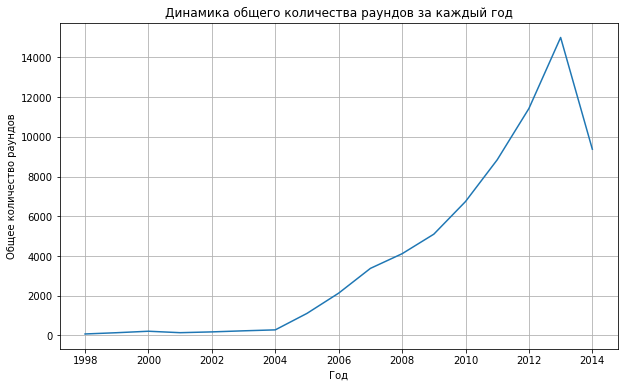

In [64]:
# Сгруппируем данные по годам и рассчитаем количество раундов
count_rounds = invest_filtered_df.groupby('mid_funding_at')['funding_rounds'].sum()

# Создаём контейнер графика matplotlib и задаём размер
plt.figure(figsize=(10, 6))

# Строим линейный график
count_rounds.plot(
                 kind='line',
                 legend=False,
                 title='Динамика общего количества раундов за каждый год')

# Настраиваем оформление графика
plt.xlabel('Год')
plt.ylabel('Общее количество раундов')

# Устанавливаем формат отображения значений на оси Y
plt.ticklabel_format(style='plain', axis='y')

# Добавляем сетку графика
plt.grid()
# Выводим график
plt.show()

In [65]:
display('Общее количество раундов за каждый год:')
count_rounds

'Общее количество раундов за каждый год:'

mid_funding_at
1998       63.0
1999      127.0
2000      201.0
2001      128.0
2002      168.0
2003      222.0
2004      270.0
2005     1101.0
2006     2122.0
2007     3369.0
2008     4108.0
2009     5093.0
2010     6739.0
2011     8843.0
2012    11429.0
2013    15008.0
2014     9376.0
Name: funding_rounds, dtype: float64


Максимальный типичный размер средств, собранный в рамках однго раунда наблюдался в `2005` году и составил `4 625 000` долларов.

В `2014` году общее количество раундов значительно снизилось по сравнению с 2012 и 2013 годами и составило `9376` раундов. Что касается типичного размера средств в рамках одного раунда в `2014` году средняя сумма повысилась по сравнению с предыдущим годом и составила `750 000` долларов.

[Назад к содержанию](#19-bullet)

---
<a class="ancor" id="16-bullet"></a>
### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберём из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразим, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у нас достаточно данных. Рассматрим только массовые сегменты, а средние и нишевые исключим.

На основе графика сделаем вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

In [66]:
# Фильтруем данные по сегментам
invest_filtered_df = invest_filtered_df[invest_filtered_df['segments'] == 'Массовые']

# Составим сводную таблицу
pivot_funding = invest_filtered_df.pivot_table(
    index=['market', 'mid_funding_at'],
    values='funding_total_usd',
    aggfunc='sum').reset_index()

In [67]:
# Отбираем данные за 2013 и 2014 года
pivot_funding_2014 = pivot_funding[pivot_funding['mid_funding_at'] == 2014]
pivot_funding_2013 = pivot_funding[pivot_funding['mid_funding_at'] == 2013]

# Суммируем funding_total_usd для каждого market в 2013 и 2014
sum_2013 = pivot_funding_2013.groupby('market')['funding_total_usd'].sum().reset_index()
sum_2014 = pivot_funding_2014.groupby('market')['funding_total_usd'].sum().reset_index()

# Объединяем данные в одну таблицу
comparative_df = pd.merge(
    sum_2013,
    sum_2014,
    on='market',
    how='inner',  # только рынки, присутствующие в обоих годах
    suffixes=('_2013', '_2014')
)

# Фильтруем сегменты, которые показали рост финансирования в 2014 году по сравнению с 2013 годом
filtered_pivot = comparative_df[
    comparative_df['funding_total_usd_2014'] > comparative_df['funding_total_usd_2013']]

In [68]:
# Выводим и сортируем значения по убыванию 'funding_total_usd_2014'
filtered_pivot.sort_values(by='funding_total_usd_2014', ascending=False)

,market,funding_total_usd_2013,funding_total_usd_2014
17,financial services,55227637.0,195618360.0
37,real estate,172350754.0,193467364.0
15,fashion,167411631.0,177075192.0
27,medical,64469424.0,175236064.0
48,technology,82461469.0,172018937.0
28,medical devices,42597864.0,171467272.0
38,saas,115100858.0,152807752.0
2,apps,79114136.0,147251866.0
23,internet,83132096.0,130655982.0
33,news,118475497.0,129478651.0


<Figure size 1440x576 with 0 Axes>

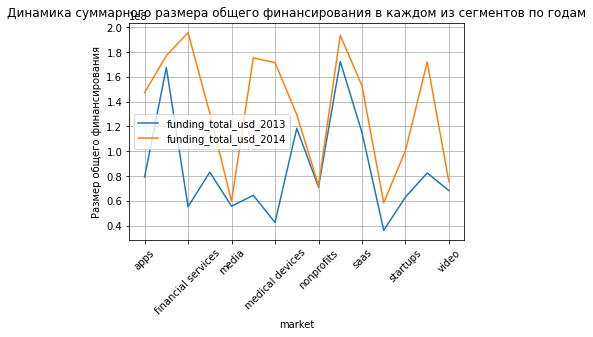

In [69]:
# Создаём контейнер графика matplotlib и задаём размер
plt.figure(figsize=(20, 8))

# Строим линейный график
filtered_pivot.plot(
                 kind='line',
                 x='market',
                 rot=45,
                 legend=True,
                 title='Динамика суммарного размера общего финансирования в каждом из сегментов по годам')

# Настраиваем оформление графика
plt.ylabel('Размер общего финансирования')

# Добавляем сетку графика
plt.grid()
# Выводим график
plt.show()

По графику и сводной таблице можно сделать вывод, что наиболее быстрый и уверенный рост показывают такие сегменты, как `financial services` (с `55 227 637.0` до `195 618 360.0`), `medical` (с `64 469 424.0` до `175 236 064.0`) и `medical devices` (с `42 597 864.0` до `171 467 272.0`), `technology` (с `82 461 469.0` до `172 018 937.0`).

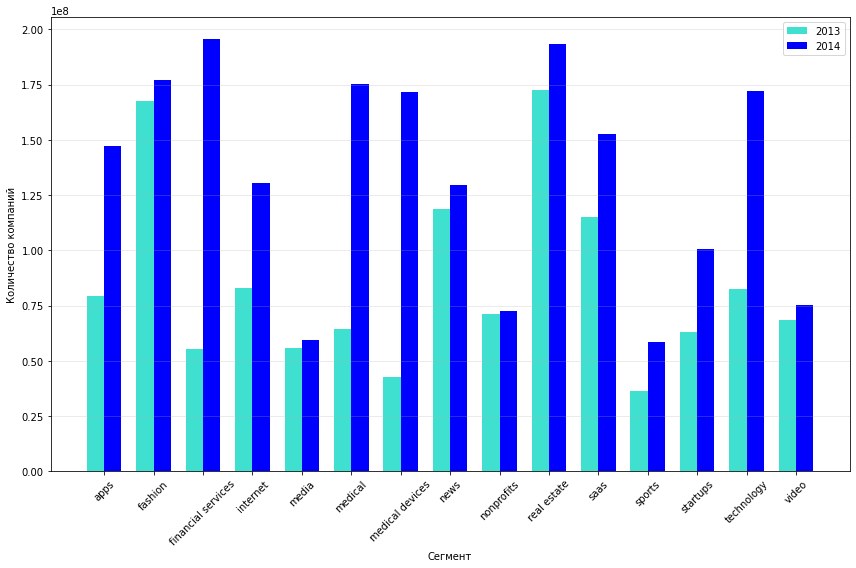

In [70]:
# Создаём контейнер графика matplotlib и задаём размер
fig, ax = plt.subplots(figsize=(12, 8))

# Разделим данные на две группы
data_2013 = filtered_pivot.groupby('market')['funding_total_usd_2013'].sum()
data_2014 = filtered_pivot.groupby('market')['funding_total_usd_2014'].sum()

# Определяем ширину столбцов и позиции на оси X
width = 0.35
x = np.arange(len(data_2013.index))  # Позиции категорий (сегментов)

# Строим столбцы для 2013 и 2014
ax.bar(x - width/2, data_2013.values, width, label='2013', color='turquoise')  # Столбцы 2013 смещены влево
ax.bar(x + width/2, data_2014.values, width, label='2014', color='blue')  # Столбцы 2014 смещены вправо

# Настраиваем оформление графика
plt.ylabel('Количество компаний')
plt.xlabel('Сегмент')
ax.set_xticks(x)  # Устанавливаем метки на оси X по центрам групп
ax.set_xticklabels(data_2013.index, rotation=45)  # Поворачиваем подписи для читаемости

# Добавляем легенду
ax.legend()

# Предотвращаем наложение элементов графика
plt.tight_layout()

# Добавляем сетку графика
plt.grid(axis='y', alpha=0.3)

# Выводим график
plt.show()

Судя по графику, значительный рост по сравнению с 2013 годом показали следующие сегменты рынка: `apps`, `internet`, `financial services`, `medical`, `medical devices`,`saas`, `startups` и `technology`.

[Назад к содержанию](#19-bullet)

---
<a class="ancor" id="17-bullet"></a>
### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Наша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, заменим на пропуски.

Совет: когда будете делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавьте к знаменателю небольшое число, например `1e-60`. Это поможет избежать деления на ноль.

In [71]:
# Выбираем пороги
for column in fin_return_df.columns:
    Q1 = fin_return_df[column].quantile(0.25)
    Q3 = fin_return_df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Оставляем только значения в пределах границ
    fin_return_df[column] = fin_return_df[column].where(
        (fin_return_df[column] >= lower_bound) & (fin_return_df[column] <= upper_bound),
        np.nan
    )

In [72]:
# Сгруппируем данные по годам
group_type_funding = invest_filtered_df.groupby('mid_funding_at')[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                                                                   'convertible_note', 'debt_financing', 'angel','grant', 
                                                                   'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
                                                                   'secondary_market', 'product_crowdfunding']].sum().reset_index()
# Используем функцию для преобразования данных
def to_millions(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    if 'e+' in value or 'e-' in value:
        try:
            return float(value) / 1_000_000
        except:
            return np.nan
    else:
        try:
            return float(value) / 1_000_000
        except:
            return np.nan
        
# Применяем только к числовым столбцам (исключаем индекс)
for col in group_type_funding.columns:
    if col != 'mid_funding_at':
        group_type_funding[col] = group_type_funding[col].apply(to_millions)

# Сделаем столбец mid_funding_at индексом group_type_funding
group_type_funding = group_type_funding.set_index('mid_funding_at') 
fin_return_df.index = fin_return_df.index.astype(int)
group_type_funding.index = group_type_funding.index.astype(int)

# Приводим индексы к int
fin_return_df.index = fin_return_df.index.astype(int)
group_type_funding.index = group_type_funding.index.astype(int)

# Выравниваем индексы (общие годы)
common_years = fin_return_df.index.intersection(group_type_funding.index)
df_return_aligned = fin_return_df.loc[common_years]
df_funding_aligned = group_type_funding.loc[common_years]


# Выравниваем колонки (общие названия)
common_cols = df_return_aligned.columns.intersection(df_funding_aligned.columns)
df_return_common = df_return_aligned[common_cols]
df_funding_common = df_funding_aligned[common_cols]

In [73]:
# Найдем нормированные значения возврата средств
normalized_values = round(df_return_common / (df_funding_common + 1e-60), 2)
display('Доля возвращённых средств от предоставленных:')
normalized_values

'Доля возвращённых средств от предоставленных:'

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
2000,1.56,0.21,0.000000e+00,1.18,0.000000e+00,2.16,0.25,0.0,0.000000e+00,2.700000e-01,0.00,3.000000e-02,0.00
2001,1.08,0.14,0.000000e+00,0.88,1.000000e+58,0.90,1.18,0.0,0.000000e+00,4.600000e+59,0.00,4.600000e+59,0.00
2002,0.70,0.72,0.000000e+00,1.10,2.000000e+58,0.24,1.14,0.0,2.000000e-01,1.130000e+00,0.00,6.000000e+58,0.00
2003,0.88,0.79,0.000000e+00,1.12,1.000000e+58,1.04,0.37,0.0,1.620000e+60,2.110000e+60,0.00,8.000000e+58,0.00
2004,0.73,0.88,0.000000e+00,5.11,1.000000e+58,0.71,0.83,0.0,2.190000e+60,3.380000e+60,0.00,5.500000e+59,0.00
2005,0.86,0.62,0.000000e+00,0.61,2.000000e+58,0.47,0.62,0.0,2.400000e+60,7.300000e-01,0.00,5.000000e+58,0.00
2006,1.02,0.41,1.900000e+59,2.68,1.700000e-01,1.13,0.78,0.0,1.220000e+00,2.058000e+61,0.00,1.200000e+59,0.00
2007,0.33,0.39,1.000000e+58,0.77,2.900000e-01,0.81,0.78,0.0,1.360000e+00,2.030000e+00,0.00,5.700000e+59,0.00
2008,0.34,0.27,3.000000e+58,0.46,1.600000e-01,1.62,0.43,0.0,3.020000e+00,8.428000e+61,0.00,4.700000e+59,0.00
2009,0.62,0.25,9.000000e-02,0.42,7.000000e-02,0.70,0.63,0.0,1.370000e+00,8.840000e+00,0.00,1.000000e-02,0.07


Построим график, на котором отобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделаем вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

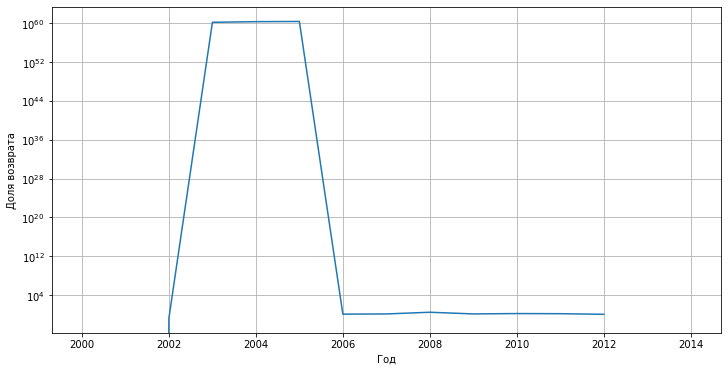

<Figure size 864x432 with 0 Axes>

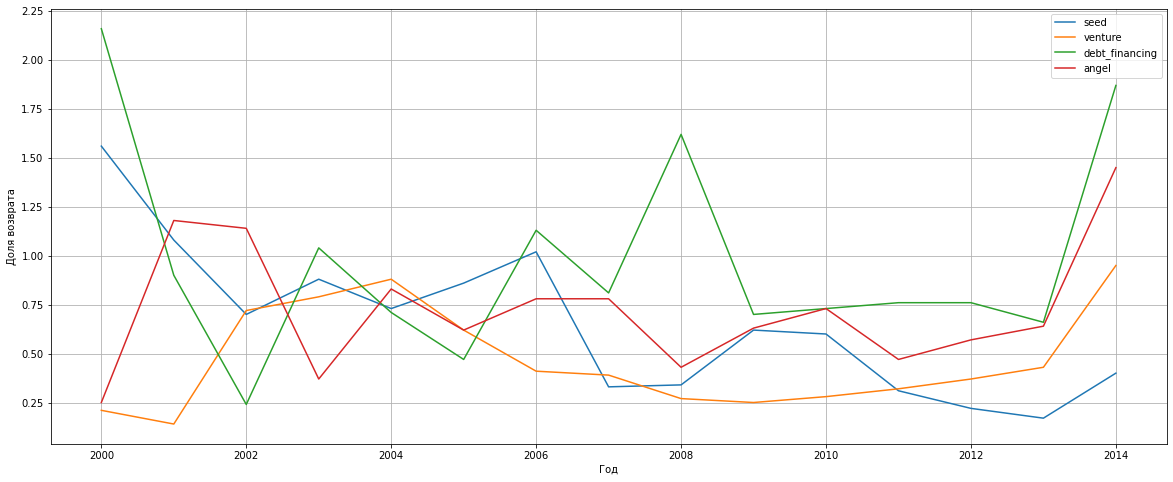

In [74]:
# Создаём контейнер графика matplotlib и задаём размер
plt.figure(figsize=(12, 6))
ax = plt.gca()

# Для столбцов с большими значениями используем логарифмическую шкалу
ax.set_yscale('log')
normalized_values['private_equity'].plot(ax=ax)

# Настраиваем оформление графика
plt.ylabel('Доля возврата')
plt.xlabel('Год')

# Добавляем сетку графика
plt.grid()

# Для остальных — линейную
plt.figure(figsize=(12, 6))
normalized_values[['seed', 'venture', 'debt_financing', 'angel']].plot(figsize=(20, 8))

# Настраиваем оформление графика
plt.ylabel('Доля возврата')
plt.xlabel('Год')

# Устанавливаем формат отображения значений на оси Y
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

# Добавляем сетку графика
plt.grid()
# Выводим график
plt.show()

Судя по графику, наиболее устойчивый рост показателей наблюдается в таких типах финансирования, как `private_equity` (прямые (частные) вложения) и `debt_financing` (долговое финансирование).

[Назад к содержанию](#19-bullet)

---
<a class="ancor" id="18-bullet"></a>
## Шаг 5. Итоговый вывод и рекомендации

В ходе исследования провели анализ данных рынка стартапов. Данные включали наименования компаний, информацию об их деятельности, инвестициях и суммах привлеченных средств. Для проведения исследований загрузили необходимые библиотеки для анализа данных и данные из датасетов `cb_investments.csv` и `cb_returns.csv`. Датасет `cb_investments.csv` содержит 54294 строки и 40 столбцов. 24 столбца с типом данных float64 и 16 столбцов с типом данных object. Датасет `cb_returns.csv` содержит `15` строк и `14` столбцов. 13 столбцов с типом данных `float64` и 1 столбец с целочисленным типом данных `int64`.

В ходе проверки и предобработки данных, была проделана следующая работа:

проверили названия столбцов в датасетах и удалили лишние пробелы. Убрали в столбце funding_total_usd выделение разрядов и приведели его к числовому типу. Обработали типы данных в столбцах founded_at, first_funding_at, last_funding_at, mid_funding_at, которые хранят значения даты и времени. В датасете cb_returns столбец year сделали индексом всего датасета. Обработали текстовые данные. Пропуски в столбцах country_code, state_code, region, founded_month, founded_quarter заполнили заглушками. Обработали полные дубликаты в данных и пропуски в funding_total_usd. Удалили те строки, которые не несут какой-либо информации, либо не содержат данных о финансировании. Заполнили пропуски в значениях mid_funding_at на основании значений в столбцах first_funding_at и last_funding_at серединой интервала между двумя датами. В ходе предобработки данных было удалено 4855 строк. Процент потерь составил 8.94.

Провели исследовательский анализ исходных данных. При исследовании данных использовали визуализации:

разделили все компании на группы по срокам финансирования и выделили массовые, средние и нишевые сегменты рынка. Для последующего анализа данных в столбце market оставили только массовые сегменты. Для остальных сегментов значения заменили на заглушки — niche для нишевых и mid для средних. 
Проанализировали выбросы в каждом из сегментов и определили компании с аномальным объёмом общего финансирования, используя метод IQR отдельно по каждому сегменту. Из датасета исключили компании, которые посчитали получившими аномальное финансирование.
Провели анализ типов финансирования по объёму и популярности. 
Выявили динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования и динамику общего количества раундов за каждый год, а также динамика размера общего финансирования по массовым сегментам рынка. 
Для каждого года и каждого вида финансирования рассчитали нормированные значения возврата средств, исключив аномальные значения путём замены на пропуски.


---
Проанализировав данные, можно сделать следующие выводы:
* В `массовом сегменте` рынка количество компаний практически в восемь раз больше остальных. Также массовые сегменты имеют наибольший разброс данных, что указывает на высокую вариативность и нестабильность финансирования. 
* Особенно популярным типом финансирования является `venture`. 
* Чаще всего компании используют `venture` (венчурные инвестиции) и `seed` (инвестиции на посевной стадии). 
* *Венчурные инвестиции (`venture`) характеризуется и большим объемом финансирования и возврата, и наиболее часто встречающимся типом финансирования.*
* *Инвестиции в виде прямых (частных) вложений (`private_equity`) встречается редко, но характеризется большим объёмом финансирования и возврата.*
* *Инвестиции от бизнес-ангелов (`angel`) встречается часто, но сумма финансирования характеризуется небольшим объёмом.*
* *Долговое финансирование после IPO (`post_ipo_debt`) характеризуется средними объёмами финансирования и возврата, но среди компаний встречается крайне редко.*

* `Максимальный типичный размер средств`, собранный в рамках однго раунда наблюдался в `1999` году. В `2014` году общее `количество раундов` значительно `снизилось` по сравнению с 2012 и 2013 годами. Что касается `типичного размера средств в рамках одного раунда` в 2014 году средняя сумма `повысилась` по сравнению с предыдущими годами.
* Наиболее быстрый и уверенный рост показывают такие сегменты, как `financial services`, `medical` и `medical devices`, `technology`. 
* Наиболее устойчивый рост показателей наблюдается в таких типах финансирования, как `private_equity` (прямые (частные) вложения) и `debt_financing` (долговое финансирование).

Анализ рынка показал, что наиболее выгодной отраслью для инвестиций является `финансовый сервис`, `медицина` и `медицинские приборы`. Эти сегменты показали рост от 22 до 40 % за 2014 год по сравнению с 2013 годом. Тип финансирования при этом лучше использовать `прямые (частные) вложения`, т.к. такие вложения характеризуются большим объёмом финансирования и возврата.

[Назад к содержанию](#19-bullet)